# Duration Prediction Benchmark — All Processes

Compares three approaches for predicting activity duration:

| Model | Features | Notes |
|---|---|---|
| **Baseline** | per-activity mean duration (from training set) | |
| **ML global (XGBoost)** | `activity` (label-encoded) + all `object_attributes` | one model for all activities |
| **ML per-activity (XGBoost)** | numeric `object_attributes` only (e.g. `total_material`) | one model per activity; avoids meaningless ID encoding |

No previous-activity features used.

**Split**: 70 % earliest case IDs → train, 30 % latest → test  
**Metrics**: MAE (minutes), R², WAPE

In [164]:
import os, sys, warnings
warnings.filterwarnings('ignore')
os.environ['TQDM_DISABLE'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

pd.options.mode.chained_assignment = None

SRC_DIR  = Path(os.path.abspath('__file__')).parent
DATA_DIR = SRC_DIR.parent / 'data' / 'gold' / 'experiment_1'
TRAIN_RATIO = 0.70

print('Setup complete.')
print('Data dir:', DATA_DIR)

Setup complete.
Data dir: /home/david/repos/process_energy_demand_modelling/data/gold/experiment_1


In [165]:
# ── Helper functions ──────────────────────────────────────────────────────────

def load_event_log(process_id):
    path = DATA_DIR / f'process_{process_id}' / 'datasets' / 'df_event_log.parquet'
    df = pd.read_parquet(path)
    df['timestamp_start'] = pd.to_datetime(df['timestamp_start'])
    df['timestamp_end']   = pd.to_datetime(df['timestamp_end'])
    df['duration'] = (
        df['timestamp_end'] - df['timestamp_start']
    ).dt.total_seconds() / 60.0
    return df


def flatten_object_attributes(df):
    if 'object_attributes' not in df.columns:
        return df
    def _parse(x):
        if isinstance(x, dict): return x
        if isinstance(x, str):
            import ast
            try: return ast.literal_eval(x)
            except: return {}
        return {}
    attrs   = df['object_attributes'].apply(_parse)
    attr_df = pd.json_normalize(attrs.tolist()).add_prefix('attr_')
    attr_df.index = df.index
    return pd.concat([df.drop(columns=['object_attributes']), attr_df], axis=1)


def add_ml_features(df):
    """Add temporal and case-context features from existing timestamps."""
    out = df.sort_values(['case_id', 'timestamp_start']).copy()
    out['feat_hour']      = out['timestamp_start'].dt.hour
    out['feat_dayofweek'] = out['timestamp_start'].dt.dayofweek
    out['feat_month']     = out['timestamp_start'].dt.month
    out['feat_act_pos']   = out.groupby('case_id').cumcount()
    out['feat_prev_dur']  = out.groupby('case_id')['duration'].shift(1).fillna(0.0)
    out['feat_prev_dur2'] = out.groupby('case_id')['duration'].shift(2).fillna(0.0)
    out['feat_case_elapsed'] = (
        out['timestamp_start']
        - out.groupby('case_id')['timestamp_start'].transform('min')
    ).dt.total_seconds() / 60.0
    return out


def temporal_split(df, train_ratio=TRAIN_RATIO):
    case_order = (
        df.groupby('case_id')['timestamp_start'].min()
        .sort_values().index.tolist()
    )
    n_train = max(1, int(len(case_order) * train_ratio))
    train_cases = set(case_order[:n_train])
    test_cases  = set(case_order[n_train:])
    return (
        df[df['case_id'].isin(train_cases)].copy(),
        df[df['case_id'].isin(test_cases)].copy(),
    )


def wape(y_true, y_pred):
    total = np.sum(np.abs(y_true))
    return np.nan if total == 0 else np.sum(np.abs(y_pred - y_true)) / total


def encode_and_build_X(df_train, df_test, feature_cols):
    train, test = df_train.copy(), df_test.copy()
    cat_cols = [c for c in feature_cols if train[c].dtype == object]
    for col in cat_cols:
        le = LabelEncoder()
        all_vals = pd.concat([train[col], test[col]]).astype(str)
        le.fit(all_vals)
        train[col] = le.transform(train[col].astype(str))
        test[col]  = le.transform(test[col].astype(str))
    X_train = train[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    X_test  = test[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    return X_train, X_test


def fit_best_dist(data, dist_dict):
    """Fit each distribution by MLE; return (name, dist, params) with lowest AIC."""
    best_name, best_dist, best_params, best_aic = None, None, None, np.inf
    for name, dist in dist_dict.items():
        try:
            params = dist.fit(data)
            ll = np.sum(dist.logpdf(data, *params))
            if not np.isfinite(ll): continue
            aic = 2 * len(params) - 2 * ll
            if aic < best_aic:
                best_aic = aic
                best_name, best_dist, best_params = name, dist, params
        except Exception:
            pass
    return best_name, best_dist, best_params


def crps_vec(samples, obs):
    """CRPS: E|X-y| - 0.5*E|X-X'|  (proper scoring rule, same units as data)."""
    e_xx = np.mean(np.abs(samples[:, None] - samples[None, :]))
    e_xy = np.mean(np.abs(samples[:, None] - obs[None, :]), axis=0)
    return e_xy - 0.5 * e_xx


# ── XGBoost per-activity (original) ──────────────────────────────────────────

def _fit_pa_model(sub, attr_cols):
    if len(sub) < 5 or not attr_cols: return None
    X = sub[attr_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    m = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                     subsample=0.8, random_state=42, verbosity=0)
    m.fit(X, sub['duration'].values)
    return m


def _oof_residuals(sub, attr_cols, n_splits=5):
    """OOF residuals for XGBoost (temporal order, no shuffle)."""
    from sklearn.model_selection import KFold
    n = len(sub)
    k = min(n_splits, n // 2)
    if k < 2 or not attr_cols: return None
    X = sub[attr_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    y = sub['duration'].values
    oof = np.full(n, np.nan)
    for tr_idx, val_idx in KFold(n_splits=k, shuffle=False).split(X):
        if len(tr_idx) < 2: continue
        m = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                         subsample=0.8, random_state=42, verbosity=0)
        m.fit(X[tr_idx], y[tr_idx])
        oof[val_idx] = y[val_idx] - m.predict(X[val_idx])
    valid = oof[~np.isnan(oof)]
    return valid if len(valid) >= 5 else None


# ── ML+: model-agnostic auto-selection on log-target + engineered features ────
#
# Candidates tried per activity — winner picked by CV MAE on log1p(duration).
# Add any sklearn-compatible regressor here; OOF residuals reuse the same folds.

MLP_ENG_COLS = [
    'feat_hour', 'feat_dayofweek', 'feat_month',
    'feat_act_pos', 'feat_prev_dur', 'feat_prev_dur2', 'feat_case_elapsed',
]

def _ridge():
    from sklearn.linear_model import Ridge
    return Ridge(alpha=1.0)

def _huber():
    from sklearn.linear_model import HuberRegressor
    return HuberRegressor(epsilon=1.35, max_iter=300)

def _rf():
    from sklearn.ensemble import RandomForestRegressor
    return RandomForestRegressor(n_estimators=50, max_depth=5,
                                 min_samples_leaf=3, random_state=42)

def _xgb():
    return XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                        subsample=0.8, random_state=42, verbosity=0)

MLP_CANDIDATES = {
    'ridge': _ridge,
    'huber': _huber,
    'rf'   : _rf,
    'xgb'  : _xgb,
}


def _fit_mlp_model_with_oof(sub, feat_cols, n_splits=5):
    """Per-activity model selection: tries all MLP_CANDIDATES by CV on log1p(duration).

    Returns ((model, scaler, model_name), oof_residuals) or (None, None).
    OOF residuals are from the CV folds of the winning candidate — no double fitting.
    """
    from sklearn.model_selection import KFold
    from sklearn.preprocessing import StandardScaler

    if len(sub) < 5 or not feat_cols:
        return None, None

    X     = sub[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    y     = sub['duration'].values
    y_log = np.log1p(y)
    n     = len(sub)
    k     = min(n_splits, n // 2)
    if k < 2:
        return None, None

    folds = list(KFold(n_splits=k, shuffle=False).split(X))

    cand_scores = {}
    cand_oofs   = {}

    for name, make_m in MLP_CANDIDATES.items():
        oof    = np.full(n, np.nan)
        scores = []
        for tr_idx, val_idx in folds:
            if len(tr_idx) < 2: continue
            from sklearn.preprocessing import StandardScaler as _SS
            sc_f = _SS()
            m_f  = make_m()
            try:
                m_f.fit(sc_f.fit_transform(X[tr_idx]), y_log[tr_idx])
                pred_log = m_f.predict(sc_f.transform(X[val_idx]))
                scores.append(np.mean(np.abs(pred_log - y_log[val_idx])))
                oof[val_idx] = y[val_idx] - np.clip(np.expm1(pred_log), 0, None)
            except Exception:
                pass
        if scores:
            cand_scores[name] = np.mean(scores)
            cand_oofs[name]   = oof

    if not cand_scores:
        return None, None

    best_name   = min(cand_scores, key=cand_scores.get)
    oof_vals    = cand_oofs[best_name]
    valid_resid = oof_vals[~np.isnan(oof_vals)]

    sc = StandardScaler()
    m  = MLP_CANDIDATES[best_name]()
    m.fit(sc.fit_transform(X), y_log)

    oof_out = valid_resid if len(valid_resid) >= 5 else None
    return (m, sc, best_name), oof_out


def _predict_mlp(model_tuple, X_raw):
    """Predict from ML+ tuple (model, scaler, name) → original duration scale."""
    m, sc = model_tuple[0], model_tuple[1]
    return np.clip(np.expm1(m.predict(sc.transform(X_raw))), 0, None)


print('Helpers defined.')
print(f'ML+ candidates: {list(MLP_CANDIDATES)}')

Helpers defined.
ML+ candidates: ['ridge', 'huber', 'rf', 'xgb']


In [166]:
# ── Feature configuration — toggle predictors on/off per process ──────────────
FEATURE_CONFIG = {
    2: {
        'activity'           : True,
        'attr_mat_id_m01_'   : False,
        'attr_mat_id_m02_'   : False,
        'attr_mat_id_m03_'   : False,
        'attr_total_material': True,
    },
    3: {
        'activity'           : True,
        'attr_none'          : False,
        'attr_total_material': True,
    },
    4: {
        'activity'                  : True,
        'attr_attr_product'         : False,
        'attr_attr_product_id'      : False,
        'attr_attr_quantity'        : False,
        'attr_attr_sfg_brix_density': False,
        'attr_attr_sfg_product_info': False,
        'attr_total_material'       : True,
    },
    5: {
        'activity'           : True,
        'attr_total_material': True,
    },
}

# ── Distribution candidates ───────────────────────────────────────────────────
DURATION_DISTS = {
    'lognorm' : stats.lognorm,
    'gamma'   : stats.gamma,
    'weibull' : stats.weibull_min,
    'expon'   : stats.expon,
}
RESIDUAL_DISTS = {
    'norm'    : stats.norm,
    'laplace' : stats.laplace,
    't'       : stats.t,
}

# ── Seeds and sample counts ───────────────────────────────────────────────────
SAMPLE_SEED  = 42
N_CRPS_EVAL  = 300

# ── Shared colours ────────────────────────────────────────────────────────────
COLORS = {
    'base': '#aec6cf',
    'ml'  : '#f4a261',
    'pa'  : '#6a9e6f',
    'dist': '#b07eb8',
    'mre' : '#e05c5c',
    'mlp' : '#42a5f5',   # ML+: Ridge + engineered features
}

print('Config loaded.')
for pid, cfg in FEATURE_CONFIG.items():
    active = [f for f, on in cfg.items() if on]
    print(f'  Process {pid}: {active}')

Config loaded.
  Process 2: ['activity', 'attr_total_material']
  Process 3: ['activity', 'attr_total_material']
  Process 4: ['activity', 'attr_total_material']
  Process 5: ['activity', 'attr_total_material']



── Process 2 — Pearson r(total_material, duration) ──
                                      n      r      p
activity                                             
Fehler Tankanwahl Bestand            38 -0.083  0.622
Warten auf Ziel                     554 -0.049  0.248
Nachlauf                            503 -0.041  0.360
Grundstellung                        75  0.004  0.976
Leitung zum Vorheizer füllen         69  0.022  0.856
Leitung zum HSM füllen               69  0.028  0.819
Produktion                          505  0.050  0.263
Materialvalidierung                 360  0.099  0.061
Spülen auf Gully                     67  0.167  0.176
Spülen mit Wasser                    67  0.192  0.120
Vorwärmen des Warmwasserkreislaufs   21  0.265  0.247
Warten auf Quelle                     4    NaN    NaN


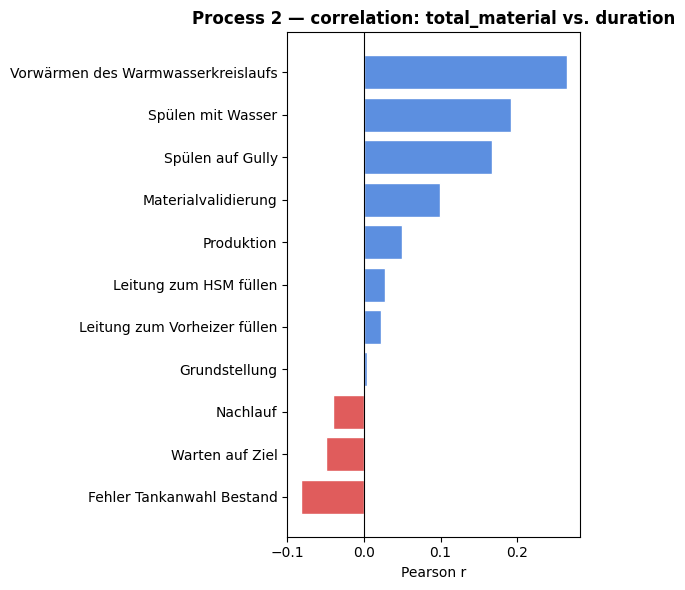


── Process 3 — Pearson r(total_material, duration) ──
                                   n      r      p
activity                                          
Stabilisiert und angepasst        33 -0.364  0.037
zurück speisen                    33 -0.283  0.110
Grundstellung                     35 -0.257  0.136
Fließbett starten für Produktion  17 -0.223  0.390
Stopp Produkt HPPx                33 -0.214  0.231
Feed vorwärts                     35 -0.119  0.496
Start Produkt HPPx                35 -0.077  0.661
Produktion                        35  0.539  0.001


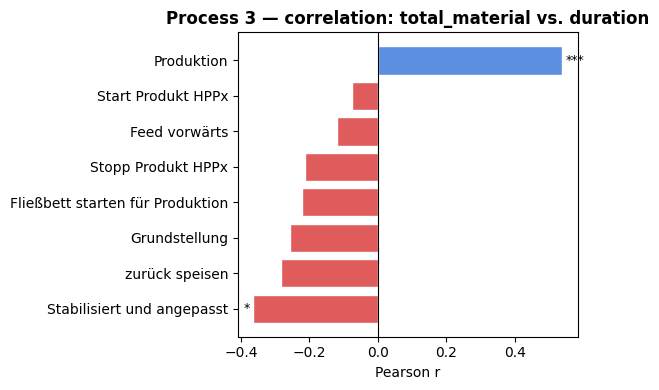


── Process 4 — Pearson r(total_material, duration) ──
                                                         n      r      p
activity                                                                
Step-025 = Füllen Anlage                                70 -0.254  0.034
Step-033 = Produkttausch                                13 -0.229  0.452
Step-035 = Ausschub Anlage                              72 -0.125  0.296
Step-023 = Sterilwasserumlauf, VLG füllen mit Produkt   47 -0.065  0.665
Step-021 = Sterilwasserumlauf, Produkt vorziehen        49 -0.040  0.786
Step-022 = Sterilwasserumlauf, VLG entleeren            49 -0.007  0.961
Step-032 = Umlauf                                      665  0.083  0.032
Step-020 = Sterilwasserumlauf (über VLG)                65  0.102  0.419
Step-024 = Sterilwasserumlauf, VLG Produktionsbereit    70  0.168  0.163
Step-030 = Produktion                                  619  0.220  0.000
Step-046 = Anlage Abfahren                               4    NaN    

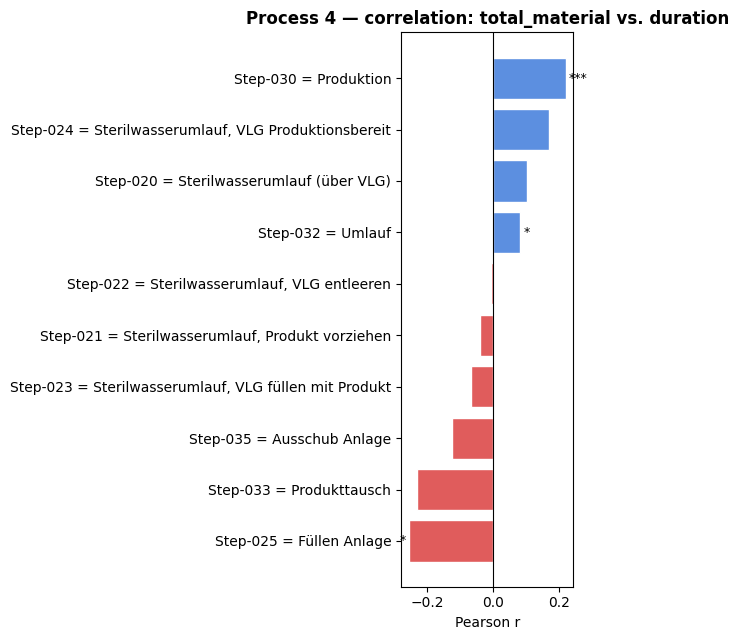


── Process 5 — Pearson r(total_material, duration) ──
                                    n      r      p
activity                                           
Fließbett starten für Produktion   24 -0.208  0.328
zurück speisen                    647 -0.136  0.001
Feed vorwärts                     614  0.010  0.803
Stabilisiert und angepasst        324  0.063  0.256
Produktion                        816  0.112  0.001


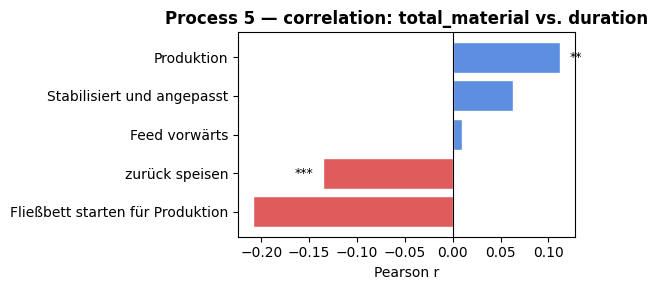

In [167]:
from scipy.stats import pearsonr

for pid in [2, 3, 4, 5]:
    try:
        df = load_event_log(pid)
        df = flatten_object_attributes(df)
        df = df[df['duration'] > 0].copy()

        if 'attr_total_material' not in df.columns:
            print(f'Process {pid}: no attr_total_material column')
            continue

        df['attr_total_material'] = pd.to_numeric(df['attr_total_material'], errors='coerce')
        df_valid = df.dropna(subset=['attr_total_material'])

        rows = []
        for act, grp in df_valid.groupby('activity'):
            if len(grp) < 5:
                rows.append({'activity': act, 'n': len(grp), 'r': np.nan, 'p': np.nan})
                continue
            r, p = pearsonr(grp['attr_total_material'], grp['duration'])
            rows.append({'activity': act, 'n': len(grp), 'r': r, 'p': p})

        corr_df = pd.DataFrame(rows).set_index('activity').sort_values('r')

        print(f'\n── Process {pid} — Pearson r(total_material, duration) ──')
        print(corr_df.round(3).to_string())

        fig, ax = plt.subplots(figsize=(6, max(3, len(corr_df) * 0.5)))
        colors = ['#e05c5c' if r < 0 else '#5c8fe0' for r in corr_df['r']]
        bars = ax.barh(corr_df.index, corr_df['r'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Pearson r')
        ax.set_title(f'Process {pid} — correlation: total_material vs. duration',
                     fontweight='bold')

        for bar, (_, row) in zip(bars, corr_df.iterrows()):
            if row['p'] < 0.05:
                sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else '*')
                xpos = bar.get_width() + (0.01 if bar.get_width() >= 0 else -0.01)
                ax.text(xpos, bar.get_y() + bar.get_height() / 2, sig,
                        ha='left' if bar.get_width() >= 0 else 'right',
                        va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        import traceback
        print(f'Process {pid} FAILED: {e}')
        traceback.print_exc()

In [168]:
def run_process(process_id):
    print(f'\n── Process {process_id} ─────────────────────────────────────')

    df = load_event_log(process_id)
    df = flatten_object_attributes(df)
    df = df[df['duration'] > 0].copy()
    df = add_ml_features(df)

    print(f'  Events: {len(df)}, cases: {df["case_id"].nunique()}, '
          f'activities: {df["activity"].nunique()}')

    cfg          = FEATURE_CONFIG[process_id]
    feature_cols = [f for f, on in cfg.items() if on]
    attr_cols    = [f for f in feature_cols if f.startswith('attr_')]
    print(f'  Active features ({len(feature_cols)}): {feature_cols}')

    df_train, df_test = temporal_split(df)
    df_test_r = df_test.reset_index(drop=True)
    print(f'  Train cases: {df_train["case_id"].nunique()} '
          f'/ Test cases: {df_test_r["case_id"].nunique()}')

    y_train = df_train['duration'].values
    y_test  = df_test_r['duration'].values

    activity_means = df_train.groupby('activity')['duration'].mean()
    global_mean    = df_train['duration'].mean()

    # Per-activity mean as a feature (target encoding — only from train, no leakage)
    df_train = df_train.copy()
    df_train['feat_act_mean_dur']  = df_train['activity'].map(activity_means).fillna(global_mean)
    df_test_r['feat_act_mean_dur'] = df_test_r['activity'].map(activity_means).fillna(global_mean)

    numeric_attr_cols = [
        c for c in attr_cols
        if pd.to_numeric(df_train[c], errors='coerce').notna().mean() > 0.5
    ]
    mlp_feat_cols = [
        c for c in (numeric_attr_cols + MLP_ENG_COLS + ['feat_act_mean_dur'])
        if c in df_train.columns
    ]

    # ── 1. Baseline: per-activity mean ────────────────────────────────────────
    y_pred_base = df_test_r['activity'].map(activity_means).fillna(global_mean).values

    # ── 2. Global XGBoost ─────────────────────────────────────────────────────
    X_train_g, X_test_g = encode_and_build_X(df_train, df_test_r, feature_cols)
    model_global = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    model_global.fit(X_train_g, y_train)
    y_pred_ml = model_global.predict(X_test_g)

    # ── 3. Per-activity XGBoost ───────────────────────────────────────────────
    act_models = {}
    for act, sub in df_train.groupby('activity'):
        m = _fit_pa_model(sub, numeric_attr_cols)
        if m is not None:
            act_models[act] = m

    # ── Activity event counts ─────────────────────────────────────────────────
    tr_counts = df_train.groupby('activity').size()
    te_counts = df_test_r.groupby('activity').size()
    all_acts  = sorted(set(tr_counts.index) | set(te_counts.index))
    print(f'\n  {"Activity":<52} {"train":>6} {"test":>5} {"model":>6}')
    print(f'  {"-"*52} {"------":>6} {"-----":>5} {"------":>6}')
    for act in sorted(all_acts, key=lambda a: -tr_counts.get(a, 0)):
        tr  = tr_counts.get(act, 0)
        te  = te_counts.get(act, 0)
        tag = 'ML' if act in act_models else ('mean' if tr >= 1 else 'unseen')
        print(f'  {act:<52} {tr:>6} {te:>5} {tag:>6}')
    print()

    y_pred_pa = np.full(len(df_test_r), np.nan)
    for act in df_test_r['activity'].unique():
        pos = df_test_r.index[df_test_r['activity'] == act]
        if act in act_models:
            X_te = df_test_r.loc[pos, numeric_attr_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
            y_pred_pa[pos] = act_models[act].predict(X_te)
        else:
            y_pred_pa[pos] = activity_means.get(act, global_mean)
    y_pred_pa[np.isnan(y_pred_pa)] = global_mean

    # ── 4. Distribution fit per activity (median as point prediction) ─────────
    act_dur_dists = {}
    for act, sub in df_train.groupby('activity'):
        if len(sub) < 5: continue
        n, d, p = fit_best_dist(sub['duration'].values, DURATION_DISTS)
        if d is not None: act_dur_dists[act] = (d, p, n)

    y_pred_dist = np.full(len(df_test_r), np.nan)
    for act in df_test_r['activity'].unique():
        pos = df_test_r.index[df_test_r['activity'] == act]
        if act in act_dur_dists:
            d, p, _ = act_dur_dists[act]
            y_pred_dist[pos] = d.median(*p)
        else:
            y_pred_dist[pos] = activity_means.get(act, global_mean)
    y_pred_dist[np.isnan(y_pred_dist)] = global_mean

    # ── 5. Per-activity XGBoost + OOF-calibrated residual distribution ────────
    act_resid_dists = {}
    for act, m in act_models.items():
        sub   = df_train[df_train['activity'] == act]
        resid = _oof_residuals(sub, numeric_attr_cols)
        if resid is None:
            X_tr  = sub[numeric_attr_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
            resid = sub['duration'].values - m.predict(X_tr)
        rn, rd, rp = fit_best_dist(resid, RESIDUAL_DISTS)
        if rd is not None: act_resid_dists[act] = (rd, rp, rn)

    np.random.seed(SAMPLE_SEED)
    y_pred_mre = np.full(len(df_test_r), np.nan)
    for act in df_test_r['activity'].unique():
        pos = df_test_r.index[df_test_r['activity'] == act]
        if act in act_models:
            X_te   = df_test_r.loc[pos, numeric_attr_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
            ml_p   = act_models[act].predict(X_te)
            if act in act_resid_dists:
                rd, rp, _ = act_resid_dists[act]
                ml_p = ml_p + rd.rvs(*rp, size=len(pos))
            y_pred_mre[pos] = ml_p
        else:
            y_pred_mre[pos] = activity_means.get(act, global_mean)
    y_pred_mre[np.isnan(y_pred_mre)] = global_mean

    # ── 6. ML+: auto model selection + temporal/context + target-encoding ─────
    act_mlp_models = {}
    for act, sub in df_train.groupby('activity'):
        model_tuple, _ = _fit_mlp_model_with_oof(sub, mlp_feat_cols)
        if model_tuple is not None:
            act_mlp_models[act] = model_tuple
    from collections import Counter as _Ctr
    _tc = _Ctr(t for _, _, t in act_mlp_models.values())
    print(f'  ML+ model selection: ' + ', '.join(f'{n}×{t}' for t, n in _tc.most_common()))

    y_pred_mlp = np.full(len(df_test_r), np.nan)
    for act in df_test_r['activity'].unique():
        pos = df_test_r.index[df_test_r['activity'] == act]
        if act in act_mlp_models:
            X_te = df_test_r.loc[pos, mlp_feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
            y_pred_mlp[pos] = _predict_mlp(act_mlp_models[act], X_te)
        else:
            y_pred_mlp[pos] = activity_means.get(act, global_mean)
    y_pred_mlp[np.isnan(y_pred_mlp)] = global_mean

    # ── Metrics ───────────────────────────────────────────────────────────────
    row = {
        'process'    : process_id,
        'train_cases': df_train['case_id'].nunique(),
        'test_cases' : df_test_r['case_id'].nunique(),
        'test_events': len(y_test),
        'n_features' : len(feature_cols),
        'base_mae' : mean_absolute_error(y_test, y_pred_base),
        'base_r2'  : r2_score(y_test, y_pred_base),
        'base_wape': wape(y_test, y_pred_base),
        'ml_mae'   : mean_absolute_error(y_test, y_pred_ml),
        'ml_r2'    : r2_score(y_test, y_pred_ml),
        'ml_wape'  : wape(y_test, y_pred_ml),
        'pa_mae'   : mean_absolute_error(y_test, y_pred_pa),
        'pa_r2'    : r2_score(y_test, y_pred_pa),
        'pa_wape'  : wape(y_test, y_pred_pa),
        'dist_mae' : mean_absolute_error(y_test, y_pred_dist),
        'dist_r2'  : r2_score(y_test, y_pred_dist),
        'dist_wape': wape(y_test, y_pred_dist),
        'mre_mae'  : mean_absolute_error(y_test, y_pred_mre),
        'mre_r2'   : r2_score(y_test, y_pred_mre),
        'mre_wape' : wape(y_test, y_pred_mre),
        'mlp_mae'  : mean_absolute_error(y_test, y_pred_mlp),
        'mlp_r2'   : r2_score(y_test, y_pred_mlp),
        'mlp_wape' : wape(y_test, y_pred_mlp),
    }

    for label, (mae, r2, wp) in [
        ('Baseline      ', (row['base_mae'],  row['base_r2'],  row['base_wape'])),
        ('ML global     ', (row['ml_mae'],    row['ml_r2'],    row['ml_wape'])),
        ('ML per-act    ', (row['pa_mae'],    row['pa_r2'],    row['pa_wape'])),
        ('Dist (median) ', (row['dist_mae'],  row['dist_r2'],  row['dist_wape'])),
        ('ML + resid    ', (row['mre_mae'],   row['mre_r2'],   row['mre_wape'])),
        ('ML+           ', (row['mlp_mae'],   row['mlp_r2'],   row['mlp_wape'])),
    ]:
        print(f'  {label}— MAE: {mae:.2f} min  R²: {r2:+.3f}  WAPE: {wp:.3f}')

    return row


all_results = []
for pid in [2, 3, 4, 5]:
    try:
        all_results.append(run_process(pid))
    except Exception as e:
        import traceback
        print(f'Process {pid} FAILED: {e}')
        traceback.print_exc()


── Process 2 ─────────────────────────────────────
  Events: 2332, cases: 49, activities: 12
  Active features (2): ['activity', 'attr_total_material']
  Train cases: 34 / Test cases: 15

  Activity                                              train  test  model
  ---------------------------------------------------- ------ ----- ------
  Warten auf Ziel                                         378   176     ML
  Produktion                                              342   163     ML
  Nachlauf                                                341   162     ML
  Materialvalidierung                                     250   110     ML
  Grundstellung                                            52    23     ML
  Leitung zum HSM füllen                                   47    22     ML
  Leitung zum Vorheizer füllen                             47    22     ML
  Spülen auf Gully                                         45    22     ML
  Spülen mit Wasser                                        45

## Results summary

In [169]:
from IPython.display import display

res = pd.DataFrame(all_results).set_index('process')

display(res[[
    'train_cases', 'test_cases', 'test_events',
    'base_mae',  'ml_mae',  'pa_mae',  'dist_mae',  'mre_mae',  'mlp_mae',
    'base_wape', 'ml_wape', 'pa_wape', 'dist_wape', 'mre_wape', 'mlp_wape',
    'base_r2',   'ml_r2',   'pa_r2',   'dist_r2',   'mre_r2',   'mlp_r2',
]].round(3).rename(columns={
    'train_cases':'train\ncases', 'test_cases':'test\ncases', 'test_events':'events',
    'base_mae':'base\nMAE',   'ml_mae':'ML-g\nMAE',   'pa_mae':'ML-pa\nMAE',
    'dist_mae':'dist\nMAE',   'mre_mae':'mre\nMAE',   'mlp_mae':'ML+\nMAE',
    'base_wape':'base\nWAPE', 'ml_wape':'ML-g\nWAPE', 'pa_wape':'ML-pa\nWAPE',
    'dist_wape':'dist\nWAPE', 'mre_wape':'mre\nWAPE', 'mlp_wape':'ML+\nWAPE',
    'base_r2':'base\nR²',     'ml_r2':'ML-g\nR²',     'pa_r2':'ML-pa\nR²',
    'dist_r2':'dist\nR²',     'mre_r2':'mre\nR²',     'mlp_r2':'ML+\nR²',
}))

,train\ncases,test\ncases,events,base\nMAE,ML-g\nMAE,ML-pa\nMAE,dist\nMAE,mre\nMAE,ML+\nMAE,base\nWAPE,...,ML-pa\nWAPE,dist\nWAPE,mre\nWAPE,ML+\nWAPE,base\nR²,ML-g\nR²,ML-pa\nR²,dist\nR²,mre\nR²,ML+\nR²
process,,,,,,,,,,,,,,,,,,,,,
2,34,15,741,20.164,38.075,19.241,14.080,6284.201,13.419,0.805,...,0.768,0.562,250.992,0.536,0.127,0.014,0.028,0.053,-678022.803,0.052
3,21,9,62,138.985,159.337,110.328,144.685,139.832,127.047,0.925,...,0.734,0.962,0.930,0.845,0.141,0.169,0.506,0.116,0.374,0.107
4,37,16,545,13.342,15.828,14.761,12.513,25.572,11.822,0.884,...,0.978,0.829,1.695,0.784,0.031,0.036,0.019,-0.130,-14.651,0.019
5,221,95,563,105.368,132.486,104.645,111.969,143.184,106.859,0.675,...,0.670,0.717,0.917,0.685,0.398,0.382,0.415,0.230,-0.084,0.297


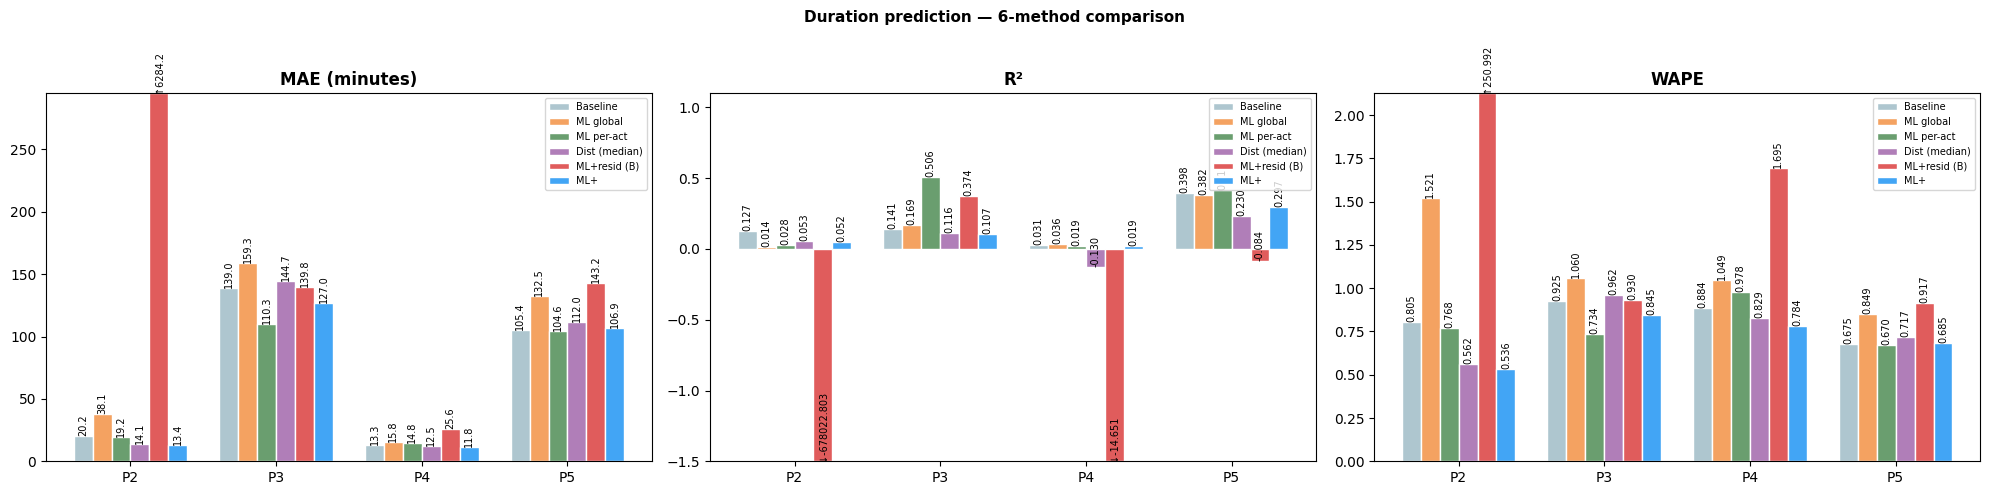

In [170]:
processes = res.index.tolist()
x      = np.arange(len(processes))
w      = 0.13
labels = [f'P{p}' for p in processes]
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * w

METHOD_ORDER = [
    ('base_mae',  'base_r2',  'base_wape',  'base', 'Baseline'),
    ('ml_mae',    'ml_r2',    'ml_wape',    'ml',   'ML global'),
    ('pa_mae',    'pa_r2',    'pa_wape',    'pa',   'ML per-act'),
    ('dist_mae',  'dist_r2',  'dist_wape',  'dist', 'Dist (median)'),
    ('mre_mae',   'mre_r2',   'mre_wape',   'mre',  'ML+resid (B)'),
    ('mlp_mae',   'mlp_r2',   'mlp_wape',   'mlp',  'ML+'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (col_idx, title, fmt) in zip(axes, [
    (0, 'MAE (minutes)', '.1f'),
    (1, 'R²',            '.3f'),
    (2, 'WAPE',          '.3f'),
]):
    # Collect all finite values to compute a sensible axis cap
    all_vals = []
    for mc, rc, wc, _, _ in METHOD_ORDER:
        col = [mc, rc, wc][col_idx]
        all_vals.extend(res[col].dropna().tolist())
    finite = [v for v in all_vals if np.isfinite(v)]

    if col_idx == 1:  # R² — cap negatives at -1.5, top at 1.1
        ylim = (max(-1.5, min(finite) - 0.05), 1.1)
    else:             # MAE / WAPE — cap at 75th-pct × 2.2 so outliers don't crush the scale
        cap  = np.percentile(finite, 75) * 2.2
        ylim = (0, cap)

    for (mc, rc, wc, ckey, label), offset in zip(METHOD_ORDER, offsets):
        col  = [mc, rc, wc][col_idx]
        vals = res[col].values

        # Clip bar height to ylim for display; mark overflows with ↑
        plot_vals = np.clip(vals, ylim[0], ylim[1])
        bars = ax.bar(x + offset, plot_vals, w,
                      label=label, color=COLORS[ckey], edgecolor='white')

        for bar, val in zip(bars, vals):
            if not np.isfinite(val):
                continue
            clipped = val > ylim[1] or val < ylim[0]
            prefix  = '↑' if val > ylim[1] else ('↓' if val < ylim[0] else '')
            y_txt   = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, y_txt,
                    f'{prefix}{val:{fmt}}',
                    ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_ylim(*ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Duration prediction — 6-method comparison', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

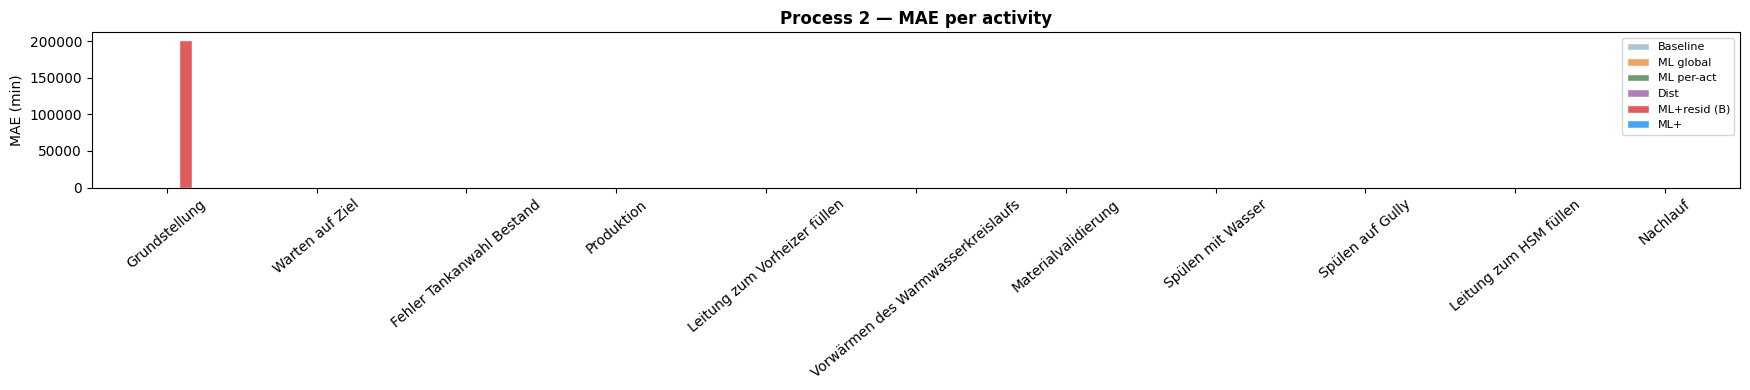

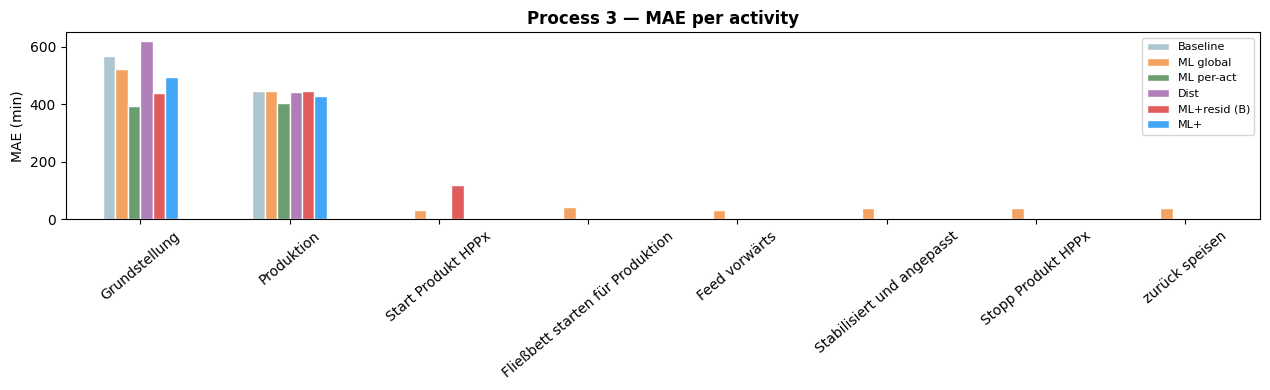

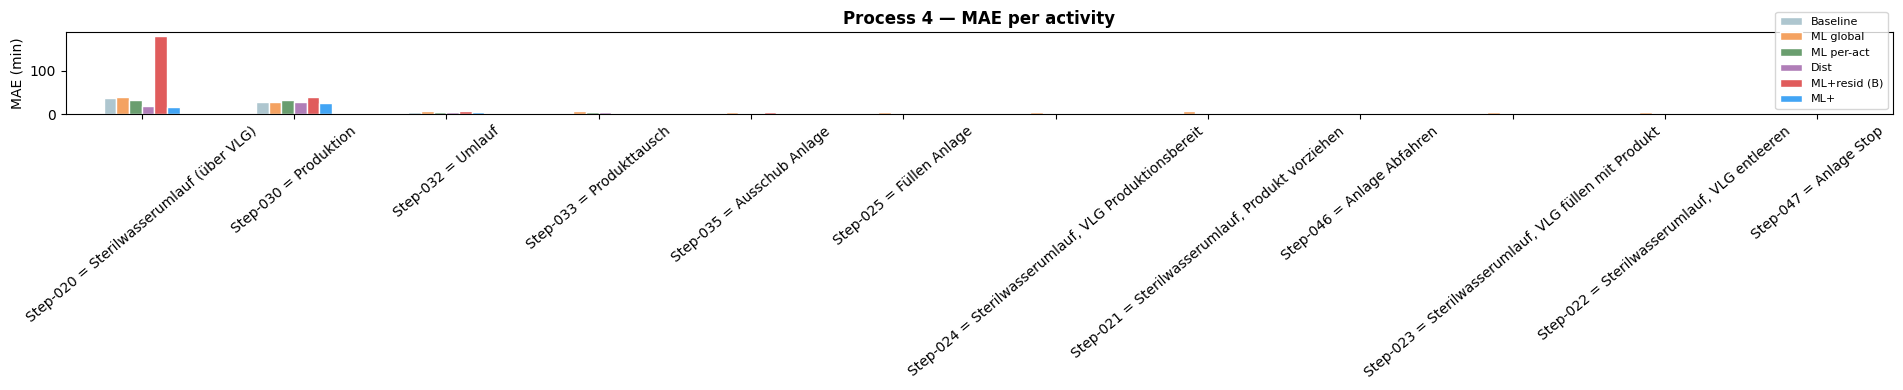

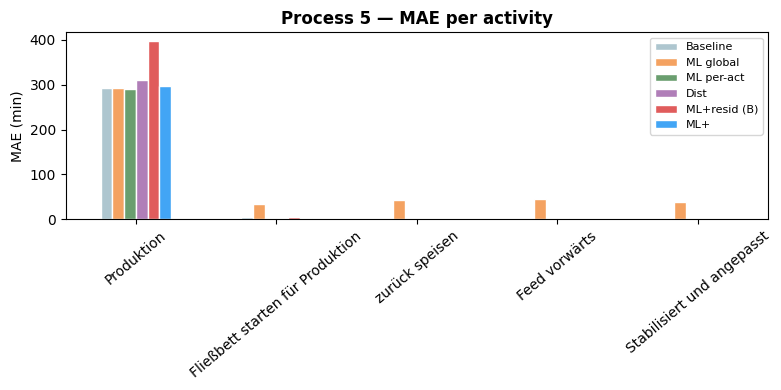

In [171]:
# Per-activity MAE breakdown — 6 methods
for pid in [2, 3, 4, 5]:
    try:
        df = load_event_log(pid)
        df = flatten_object_attributes(df)
        df = df[df['duration'] > 0].copy()
        df = add_ml_features(df)

        cfg          = FEATURE_CONFIG[pid]
        feature_cols = [f for f, on in cfg.items() if on]
        attr_cols    = [f for f in feature_cols if f.startswith('attr_')]
        num_cols     = [c for c in attr_cols
                        if pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.5]

        df_train, df_test = temporal_split(df)
        df_test_r = df_test.reset_index(drop=True)
        y_test = df_test_r['duration'].values

        activity_means = df_train.groupby('activity')['duration'].mean()
        global_mean    = df_train['duration'].mean()

        df_train = df_train.copy()
        df_train['feat_act_mean_dur']  = df_train['activity'].map(activity_means).fillna(global_mean)
        df_test_r['feat_act_mean_dur'] = df_test_r['activity'].map(activity_means).fillna(global_mean)

        mlp_cols = [
            c for c in (num_cols + MLP_ENG_COLS + ['feat_act_mean_dur'])
            if c in df_train.columns
        ]

        # Baseline
        y_pred_base = df_test_r['activity'].map(activity_means).fillna(global_mean).values

        # ML global
        X_train_g, X_test_g = encode_and_build_X(df_train, df_test_r, feature_cols)
        model_g = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
        model_g.fit(X_train_g, df_train['duration'].values)
        y_pred_ml = model_g.predict(X_test_g)

        # ML per-act (XGBoost)
        act_models = {}
        for act, sub in df_train.groupby('activity'):
            m = _fit_pa_model(sub, num_cols)
            if m is not None: act_models[act] = m

        y_pred_pa = np.full(len(df_test_r), np.nan)
        for act in df_test_r['activity'].unique():
            pos = df_test_r.index[df_test_r['activity'] == act]
            if act in act_models:
                X_te = df_test_r.loc[pos, num_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                y_pred_pa[pos] = act_models[act].predict(X_te)
            else:
                y_pred_pa[pos] = activity_means.get(act, global_mean)
        y_pred_pa[np.isnan(y_pred_pa)] = global_mean

        # Dist (median)
        act_dur_dists = {}
        for act, sub in df_train.groupby('activity'):
            if len(sub) < 5: continue
            n, d, p = fit_best_dist(sub['duration'].values, DURATION_DISTS)
            if d is not None: act_dur_dists[act] = (d, p)

        y_pred_dist = np.full(len(df_test_r), np.nan)
        for act in df_test_r['activity'].unique():
            pos = df_test_r.index[df_test_r['activity'] == act]
            if act in act_dur_dists:
                d, p = act_dur_dists[act]
                y_pred_dist[pos] = d.median(*p)
            else:
                y_pred_dist[pos] = activity_means.get(act, global_mean)
        y_pred_dist[np.isnan(y_pred_dist)] = global_mean

        # ML+resid (OOF XGBoost)
        act_resid_dists = {}
        for act, m in act_models.items():
            sub   = df_train[df_train['activity'] == act]
            resid = _oof_residuals(sub, num_cols)
            if resid is None:
                X_tr  = sub[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                resid = sub['duration'].values - m.predict(X_tr)
            rn, rd, rp = fit_best_dist(resid, RESIDUAL_DISTS)
            if rd is not None: act_resid_dists[act] = (rd, rp)

        np.random.seed(SAMPLE_SEED)
        y_pred_mre = np.full(len(df_test_r), np.nan)
        for act in df_test_r['activity'].unique():
            pos = df_test_r.index[df_test_r['activity'] == act]
            if act in act_models:
                X_te = df_test_r.loc[pos, num_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                ml_p = act_models[act].predict(X_te)
                if act in act_resid_dists:
                    rd, rp = act_resid_dists[act]
                    ml_p = ml_p + rd.rvs(*rp, size=len(pos))
                y_pred_mre[pos] = ml_p
            else:
                y_pred_mre[pos] = activity_means.get(act, global_mean)
        y_pred_mre[np.isnan(y_pred_mre)] = global_mean

        # ML+ (auto model selection, log-target, engineered + target-encoding features)
        act_mlp_models = {}
        for act, sub in df_train.groupby('activity'):
            model_tuple, _ = _fit_mlp_model_with_oof(sub, mlp_cols)
            if model_tuple is not None: act_mlp_models[act] = model_tuple

        y_pred_mlp = np.full(len(df_test_r), np.nan)
        for act in df_test_r['activity'].unique():
            pos = df_test_r.index[df_test_r['activity'] == act]
            if act in act_mlp_models:
                X_te = df_test_r.loc[pos, mlp_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                y_pred_mlp[pos] = _predict_mlp(act_mlp_models[act], X_te)
            else:
                y_pred_mlp[pos] = activity_means.get(act, global_mean)
        y_pred_mlp[np.isnan(y_pred_mlp)] = global_mean

        for col, pred in [
            ('err_base', y_pred_base), ('err_ml',  y_pred_ml),
            ('err_pa',   y_pred_pa),   ('err_dist', y_pred_dist),
            ('err_mre',  y_pred_mre),  ('err_mlp',  y_pred_mlp),
        ]:
            df_test_r[col] = np.abs(pred - y_test)

        act_err = (
            df_test_r.groupby('activity')
            [['err_base','err_ml','err_pa','err_dist','err_mre','err_mlp']]
            .mean().sort_values('err_base', ascending=False)
            .rename(columns={
                'err_base':'Baseline', 'err_ml':'ML global', 'err_pa':'ML per-act',
                'err_dist':'Dist',     'err_mre':'ML+resid (B)', 'err_mlp':'ML+',
            })
        )
        n_act = len(act_err)
        fig, ax = plt.subplots(figsize=(max(8, n_act * 1.6), 4))
        act_err.plot(kind='bar', ax=ax,
                     color=[COLORS[k] for k in ('base','ml','pa','dist','mre','mlp')],
                     edgecolor='white')
        ax.set_title(f'Process {pid} — MAE per activity', fontweight='bold')
        ax.set_xlabel(''); ax.set_ylabel('MAE (min)')
        ax.tick_params(axis='x', rotation=40); ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

    except Exception as e:
        import traceback
        print(f'Process {pid} failed: {e}'); traceback.print_exc()

## Distributional evaluation

Compare the two distributional methods on **proper scoring rules** — metrics that reward the full predictive distribution, not just the point prediction:

| Metric | What it measures | Target |
|---|---|---|
| **NLL** | −mean log-likelihood of test obs under predicted distribution | lower = better |
| **CRPS** | Continuous Ranked Probability Score — generalises MAE to distributions; shift-equivariant so A and B are on the same minute scale | lower = better |
| **80% coverage** | Fraction of test obs inside the 80% prediction interval | 0.80 = perfect |

**Calibration (PIT plot)**: if F(y) ~ Uniform[0,1] the model is perfectly calibrated → diagonal line. Above diagonal = intervals too narrow (overconfident). Below = too wide.

- **Method A**: distribution fitted directly to training durations per activity  
- **Method B**: per-activity XGBoost predicts the mean; residual distribution is fitted and sampled at test time

In [172]:
# ── Distributional evaluation: NLL, CRPS, 80% coverage ───────────────────────

eval_rows = []
pit_A_all = []
pit_B_all = []
pit_C_all = []

for pid in [2, 3, 4, 5]:
    try:
        df = load_event_log(pid)
        df = flatten_object_attributes(df)
        df = df[df['duration'] > 0].copy()
        df = add_ml_features(df)

        cfg           = FEATURE_CONFIG[pid]
        feature_cols  = [f for f, on in cfg.items() if on]
        attr_cols     = [f for f in feature_cols if f.startswith('attr_')]
        num_attr_cols = [c for c in attr_cols
                         if pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.5]

        df_train, df_test = temporal_split(df)
        df_test_r = df_test.reset_index(drop=True)

        activity_means = df_train.groupby('activity')['duration'].mean()
        global_mean    = df_train['duration'].mean()

        df_train = df_train.copy()
        df_train['feat_act_mean_dur']  = df_train['activity'].map(activity_means).fillna(global_mean)
        df_test_r['feat_act_mean_dur'] = df_test_r['activity'].map(activity_means).fillna(global_mean)

        mlp_feat_cols = [
            c for c in (num_attr_cols + MLP_ENG_COLS + ['feat_act_mean_dur'])
            if c in df_train.columns
        ]

        # ── Method A: fit distribution to training durations ──────────────────
        act_dur_dists = {}
        for act, sub in df_train.groupby('activity'):
            if len(sub) < 5: continue
            n, d, p = fit_best_dist(sub['duration'].values, DURATION_DISTS)
            if d is not None: act_dur_dists[act] = (d, p, n)

        # ── Method B: XGBoost per-act + OOF residual dist ─────────────────────
        act_models_b      = {}
        act_resid_dists_b = {}
        for act, sub in df_train.groupby('activity'):
            if len(sub) < 5 or not num_attr_cols: continue
            m = _fit_pa_model(sub, num_attr_cols)
            if m is None: continue
            act_models_b[act] = m
            resid = _oof_residuals(sub, num_attr_cols)
            if resid is None:
                X_tr  = sub[num_attr_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                resid = sub['duration'].values - m.predict(X_tr)
            rn, rd, rp = fit_best_dist(resid, RESIDUAL_DISTS)
            if rd is not None: act_resid_dists_b[act] = (rd, rp, rn)

        # ── Method C: ML+ (auto model selection) + OOF residual dist ─────────
        act_models_c      = {}
        act_resid_dists_c = {}
        for act, sub in df_train.groupby('activity'):
            model_tuple, oof_resid = _fit_mlp_model_with_oof(sub, mlp_feat_cols)
            if model_tuple is None: continue
            act_models_c[act] = model_tuple
            if oof_resid is None:
                X_tr      = sub[mlp_feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                oof_resid = sub['duration'].values - _predict_mlp(model_tuple, X_tr)
            rn, rd, rp = fit_best_dist(oof_resid, RESIDUAL_DISTS)
            if rd is not None: act_resid_dists_c[act] = (rd, rp, rn)

        # ── Evaluate per test activity ────────────────────────────────────────
        for act in df_test_r['activity'].unique():
            pos   = df_test_r.index[df_test_r['activity'] == act]
            y_act = df_test_r.loc[pos, 'duration'].values
            if len(y_act) == 0: continue

            row = {'process': pid, 'activity': act, 'n': len(y_act)}

            if act in act_dur_dists:
                d_a, p_a, n_a = act_dur_dists[act]
                row['A_dist'] = n_a
                ll_a = d_a.logpdf(y_act, *p_a)
                row['A_nll']  = float(-np.mean(ll_a[np.isfinite(ll_a)]))
                np.random.seed(42)
                samp_a = d_a.rvs(*p_a, size=N_CRPS_EVAL)
                row['A_crps']  = float(np.mean(crps_vec(samp_a, y_act)))
                lo_a, hi_a    = d_a.ppf(0.10, *p_a), d_a.ppf(0.90, *p_a)
                row['A_cov80'] = float(np.mean((y_act >= lo_a) & (y_act <= hi_a)))
                pit_A_all.extend(d_a.cdf(y_act, *p_a).tolist())
            else:
                row.update({'A_dist':'n/a','A_nll':np.nan,'A_crps':np.nan,'A_cov80':np.nan})

            if act in act_models_b and act in act_resid_dists_b:
                X_te     = df_test_r.loc[pos, num_attr_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                ml_p     = act_models_b[act].predict(X_te)
                rd, rp, rn = act_resid_dists_b[act]
                row['B_dist'] = rn
                resid_t = y_act - ml_p
                ll_b = rd.logpdf(resid_t, *rp)
                row['B_nll']   = float(-np.mean(ll_b[np.isfinite(ll_b)]))
                np.random.seed(42)
                samp_b = rd.rvs(*rp, size=N_CRPS_EVAL)
                row['B_crps']  = float(np.mean(crps_vec(samp_b, resid_t)))
                r_lo, r_hi     = rd.ppf(0.10, *rp), rd.ppf(0.90, *rp)
                row['B_cov80'] = float(np.mean((resid_t >= r_lo) & (resid_t <= r_hi)))
                pit_B_all.extend(rd.cdf(resid_t, *rp).tolist())
            else:
                row.update({'B_dist':'n/a','B_nll':np.nan,'B_crps':np.nan,'B_cov80':np.nan})

            if act in act_models_c and act in act_resid_dists_c:
                X_te_c   = df_test_r.loc[pos, mlp_feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
                mlp_p    = _predict_mlp(act_models_c[act], X_te_c)
                rd, rp, rn = act_resid_dists_c[act]
                row['C_dist'] = rn
                resid_t_c = y_act - mlp_p
                ll_c = rd.logpdf(resid_t_c, *rp)
                row['C_nll']   = float(-np.mean(ll_c[np.isfinite(ll_c)]))
                np.random.seed(42)
                samp_c = rd.rvs(*rp, size=N_CRPS_EVAL)
                row['C_crps']  = float(np.mean(crps_vec(samp_c, resid_t_c)))
                r_lo_c, r_hi_c = rd.ppf(0.10, *rp), rd.ppf(0.90, *rp)
                row['C_cov80'] = float(np.mean((resid_t_c >= r_lo_c) & (resid_t_c <= r_hi_c)))
                pit_C_all.extend(rd.cdf(resid_t_c, *rp).tolist())
            else:
                row.update({'C_dist':'n/a','C_nll':np.nan,'C_crps':np.nan,'C_cov80':np.nan})

            eval_rows.append(row)

        print(f'Process {pid}: {sum(r["process"]==pid for r in eval_rows)} activities evaluated')

    except Exception as e:
        import traceback
        print(f'Process {pid} FAILED: {e}'); traceback.print_exc()

eval_df = pd.DataFrame(eval_rows)
print(eval_df[['process','activity','n',
               'A_dist','A_nll','A_crps','A_cov80',
               'B_dist','B_nll','B_crps','B_cov80',
               'C_dist','C_nll','C_crps','C_cov80']].round(3).to_string())

Process 2: 11 activities evaluated
Process 3: 8 activities evaluated
Process 4: 12 activities evaluated
Process 5: 5 activities evaluated
    process                                               activity    n   A_dist   A_nll        A_crps  A_cov80   B_dist  B_nll   B_crps  B_cov80   C_dist   C_nll   C_crps  C_cov80
0         2                     Vorwärmen des Warmwasserkreislaufs    9  lognorm  -9.173  6.663213e+13    0.667     norm -0.467    0.090    0.667     norm  -0.613    0.078    0.778
1         2                                        Warten auf Ziel  176  lognorm   4.749  1.573900e+01    0.835        t  5.496   31.479    0.580        t   4.469   14.719    0.824
2         2                                    Materialvalidierung  110  lognorm -30.542  3.617560e+04    0.882        t -0.810    0.100    0.545        t -11.875    0.033    0.882
3         2                           Leitung zum Vorheizer füllen   22  lognorm   1.198  3.420000e-01    0.864        t  2.226    1.731  

── Distributional metrics — n-weighted mean across activities ──


,A NLL,A CRPS,A cov80,B NLL,B CRPS,B cov80,C NLL,C CRPS,C cov80
process,,,,,,,,,
2,-3.639,7.499295e+13,0.841,0.986,30.113,0.686,-4.445,12.457,0.823
3,-0.601,5.406553e+16,0.758,3.415,93.948,0.629,3.364,108.473,0.677
4,2.842,1.054127e+14,0.754,3.745,11.325,0.671,3.579,10.127,0.640
5,-0.694,7.410183e+16,0.854,2.793,81.294,0.824,-1.071,78.046,0.833


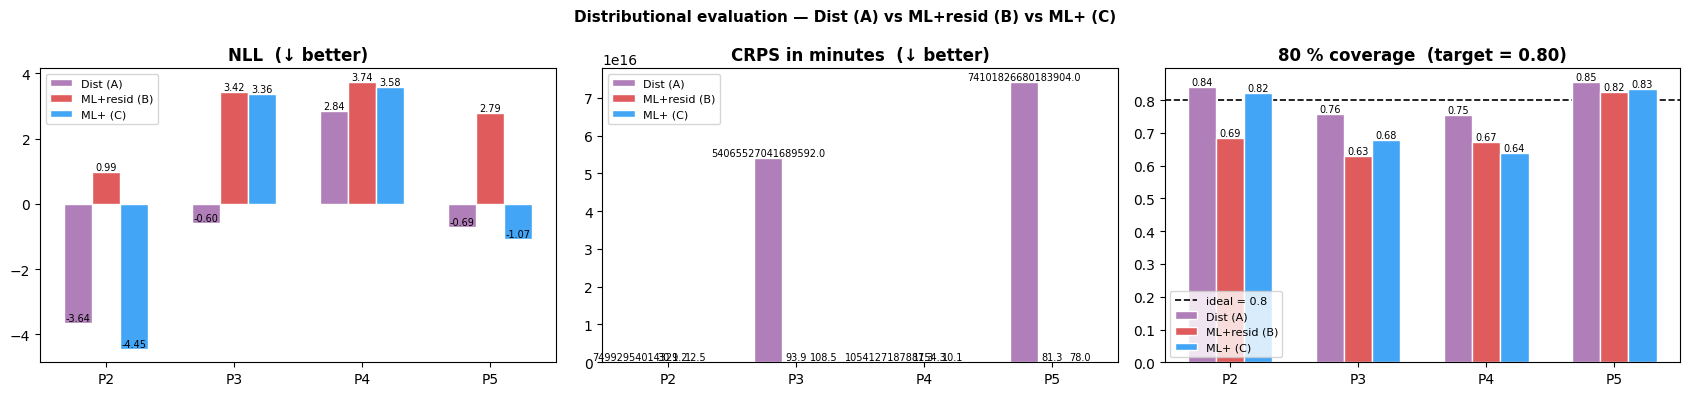

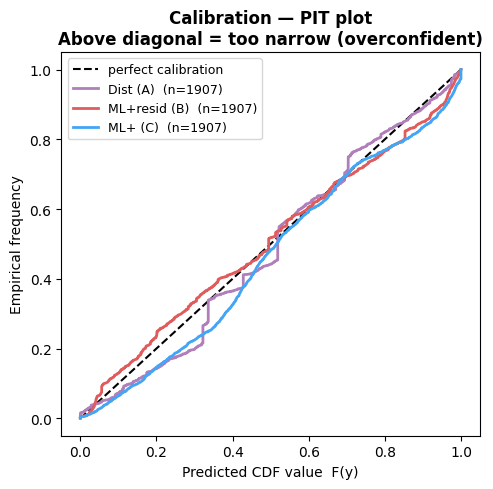

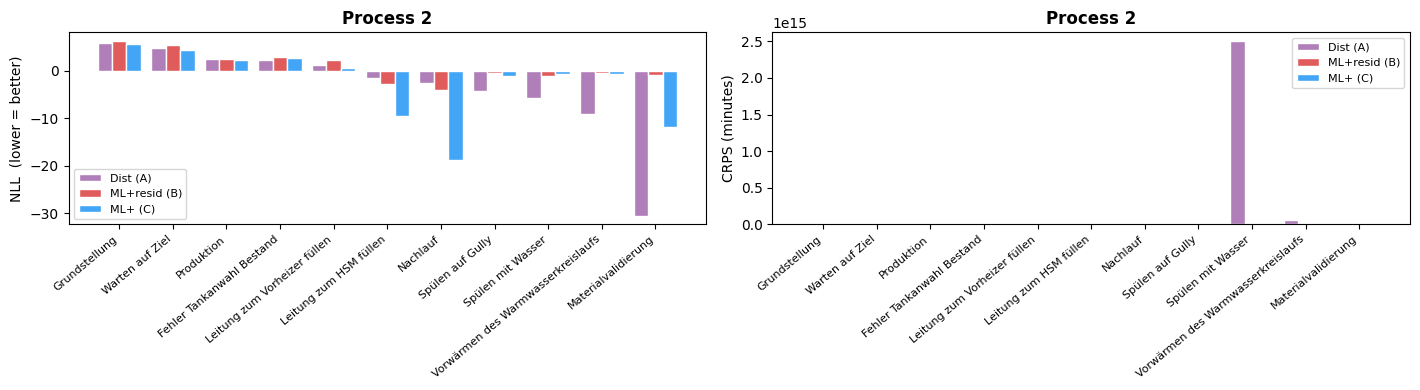

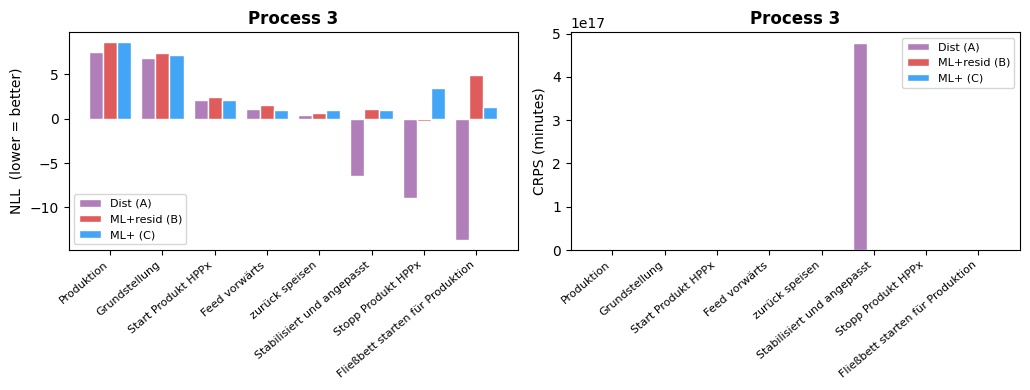

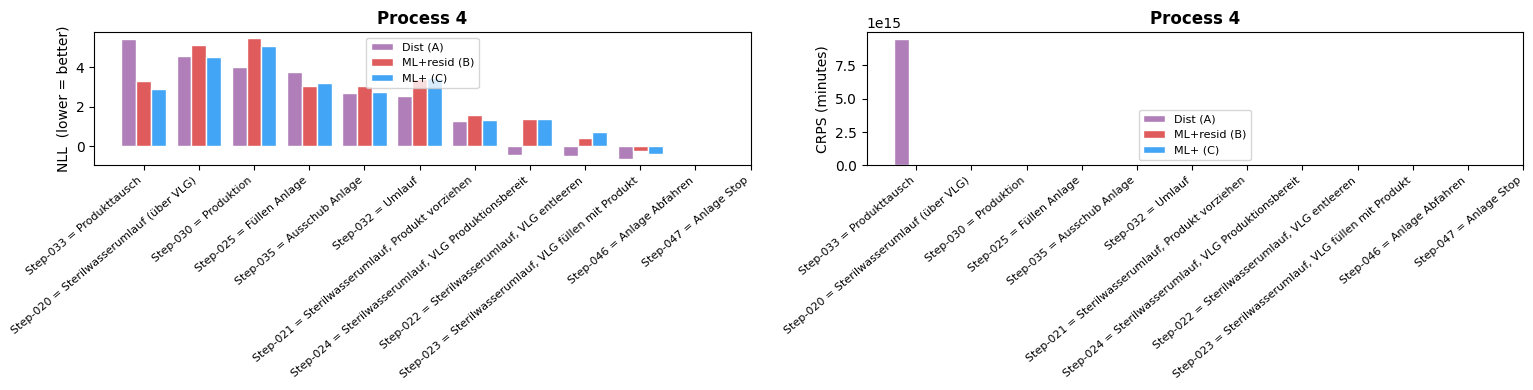

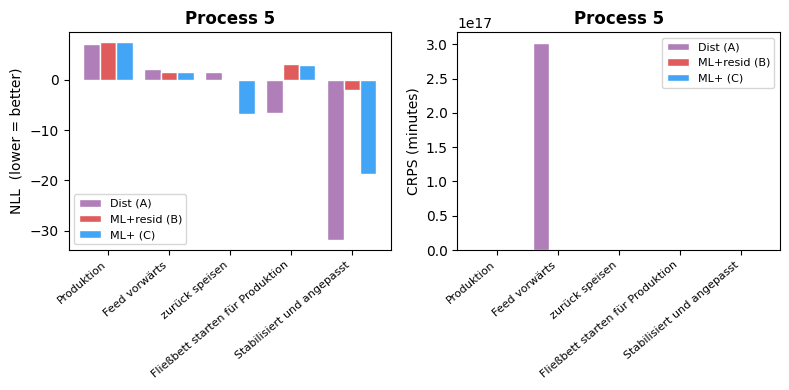

In [173]:
from IPython.display import display

# ── Process-level summary (n-weighted mean across activities) ─────────────────
def wt_nanmean(g, col):
    mask = g[col].notna()
    if mask.sum() == 0: return np.nan
    return np.average(g.loc[mask, col], weights=g.loc[mask, 'n'])

summary = (
    eval_df.groupby('process')
    .apply(lambda g: pd.Series({
        k: wt_nanmean(g, k)
        for k in ['A_nll','A_crps','A_cov80',
                  'B_nll','B_crps','B_cov80',
                  'C_nll','C_crps','C_cov80']
    }))
)
print('── Distributional metrics — n-weighted mean across activities ──')
display(summary.round(3).rename(columns={
    'A_nll':'A NLL',  'A_crps':'A CRPS',  'A_cov80':'A cov80',
    'B_nll':'B NLL',  'B_crps':'B CRPS',  'B_cov80':'B cov80',
    'C_nll':'C NLL',  'C_crps':'C CRPS',  'C_cov80':'C cov80',
}))

# ── Bar charts: NLL, CRPS, Coverage ──────────────────────────────────────────
processes = summary.index.tolist()
x = np.arange(len(processes))
w = 0.22
labels = [f'P{p}' for p in processes]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (a_col, b_col, c_col, title, fmt, ref) in zip(axes, [
    ('A_nll',   'B_nll',   'C_nll',   'NLL  (↓ better)',               '.2f', None),
    ('A_crps',  'B_crps',  'C_crps',  'CRPS in minutes  (↓ better)',   '.1f', None),
    ('A_cov80', 'B_cov80', 'C_cov80', '80 % coverage  (target = 0.80)', '.2f', 0.80),
]):
    ba = ax.bar(x - w,   summary[a_col], w, label='Dist (A)',      color=COLORS['dist'], edgecolor='white')
    bb = ax.bar(x,       summary[b_col], w, label='ML+resid (B)',  color=COLORS['mre'],  edgecolor='white')
    bc = ax.bar(x + w,   summary[c_col], w, label='ML+ (C)',       color=COLORS['mlp'],  edgecolor='white')
    if ref is not None:
        ax.axhline(ref, color='black', linewidth=1.2, linestyle='--', zorder=0, label=f'ideal = {ref}')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    for bar in list(ba) + list(bb) + list(bc):
        h = bar.get_height()
        if np.isfinite(h):
            ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:{fmt}}',
                    ha='center', va='bottom', fontsize=7)

plt.suptitle('Distributional evaluation — Dist (A) vs ML+resid (B) vs ML+ (C)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

# ── Calibration / PIT plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='perfect calibration')
for pit_vals, label, color in [
    (pit_A_all, 'Dist (A)',      COLORS['dist']),
    (pit_B_all, 'ML+resid (B)',  COLORS['mre']),
    (pit_C_all, 'ML+ (C)',       COLORS['mlp']),
]:
    v = np.sort([p for p in pit_vals if np.isfinite(p)])
    n = len(v)
    if n > 0:
        ax.plot(v, np.arange(1, n + 1) / n, color=color, label=f'{label}  (n={n})', lw=2)

ax.set_xlabel('Predicted CDF value  F(y)')
ax.set_ylabel('Empirical frequency')
ax.set_title('Calibration — PIT plot\nAbove diagonal = too narrow (overconfident)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Per-activity NLL and CRPS ─────────────────────────────────────────────────
for pid in [2, 3, 4, 5]:
    sub = eval_df[eval_df['process'] == pid].set_index('activity').sort_values('A_nll', ascending=False)
    if sub.empty: continue
    n_act = len(sub)
    x_a   = np.arange(n_act)

    fig, axes = plt.subplots(1, 2, figsize=(max(8, n_act * 1.3), 4))
    for ax, (a_col, b_col, c_col, ylabel) in zip(axes, [
        ('A_nll',  'B_nll',  'C_nll',  'NLL  (lower = better)'),
        ('A_crps', 'B_crps', 'C_crps', 'CRPS (minutes)'),
    ]):
        ax.bar(x_a - 0.27, sub[a_col], 0.27, label='Dist (A)',     color=COLORS['dist'], edgecolor='white')
        ax.bar(x_a,        sub[b_col], 0.27, label='ML+resid (B)', color=COLORS['mre'],  edgecolor='white')
        ax.bar(x_a + 0.27, sub[c_col], 0.27, label='ML+ (C)',      color=COLORS['mlp'],  edgecolor='white')
        ax.set_xticks(x_a)
        ax.set_xticklabels(sub.index, rotation=40, ha='right', fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(f'Process {pid}', fontweight='bold')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [174]:
from IPython.display import display

# ── Helper: style a df so the best cell per row is green ─────────────────────
def _style_min(df, fmt='{:.1f}'):
    return df.style.highlight_min(axis=1, color='#b7e4c7').format(fmt)

def _style_closest(df, target, fmt='{:.2f}'):
    def row_style(row):
        dist = (df.loc[row.name] - target).abs()
        return ['background-color: #b7e4c7' if col == dist.idxmin() else ''
                for col in df.columns]
    return df.style.apply(row_style, axis=1).format(fmt)

# ── Point-prediction MAE ──────────────────────────────────────────────────────
mae_cols = {
    'base_mae' : 'Baseline',
    'pa_mae'   : 'ML per-act',
    'dist_mae' : 'Dist (A)',
    'mre_mae'  : 'ML+resid (B)',
    'mlp_mae'  : 'ML+ (C)',
}
mae_df = res[list(mae_cols)].rename(columns=mae_cols).copy()
mae_df.index = [f'P{p}' for p in mae_df.index]
mae_df['★ winner'] = mae_df.idxmin(axis=1)

print('── MAE (minutes) — lower is better — green cell = winner ──────')
display(_style_min(mae_df.drop(columns='★ winner')).set_caption(
    '★ winner: ' + '  |  '.join(f'P{p}→{w}' for p, w in zip(res.index, mae_df['★ winner']))))

# ── Distributional CRPS ───────────────────────────────────────────────────────
crps_cols = {'A_crps': 'Dist (A)', 'B_crps': 'ML+resid (B)', 'C_crps': 'ML+ (C)'}
crps_df = summary[list(crps_cols)].rename(columns=crps_cols).copy()
crps_df.index = [f'P{p}' for p in crps_df.index]
crps_df['★ winner'] = crps_df.idxmin(axis=1)

print('\n── CRPS (minutes) — lower is better — green cell = winner ─────')
display(_style_min(crps_df.drop(columns='★ winner'), fmt='{:.2f}').set_caption(
    '★ winner: ' + '  |  '.join(f'P{p}→{w}' for p, w in zip(summary.index, crps_df['★ winner']))))

# ── 80% coverage — closest to 0.80 wins ──────────────────────────────────────
cov_cols = {'A_cov80': 'Dist (A)', 'B_cov80': 'ML+resid (B)', 'C_cov80': 'ML+ (C)'}
cov_df = summary[list(cov_cols)].rename(columns=cov_cols).copy()
cov_df.index = [f'P{p}' for p in cov_df.index]
cov_df['★ winner'] = (cov_df - 0.80).abs().idxmin(axis=1)

print('\n── 80% Coverage — closest to 0.80 is best — green cell = winner')
display(_style_closest(cov_df.drop(columns='★ winner'), target=0.80).set_caption(
    '★ winner: ' + '  |  '.join(f'P{p}→{w}' for p, w in zip(summary.index, cov_df['★ winner']))))

# ── Overall win count ─────────────────────────────────────────────────────────
print('\n── Win count across all processes ──────────────────────────────')
from collections import Counter
wc = Counter(list(mae_df['★ winner']) + list(crps_df['★ winner']) + list(cov_df['★ winner']))
for method, n in sorted(wc.items(), key=lambda x: -x[1]):
    print(f'  {method:<16}  {"█" * n}  ({n})')

── MAE (minutes) — lower is better — green cell = winner ──────


,Baseline,ML per-act,Dist (A),ML+resid (B),ML+ (C)
P2,20.2,19.2,14.1,6284.2,13.4
P3,139.0,110.3,144.7,139.8,127.0
P4,13.3,14.8,12.5,25.6,11.8
P5,105.4,104.6,112.0,143.2,106.9



── CRPS (minutes) — lower is better — green cell = winner ─────


,Dist (A),ML+resid (B),ML+ (C)
P2,74992954014329.16,30.11,12.46
P3,54065527041689592.00,93.95,108.47
P4,105412718788754.30,11.32,10.13
P5,74101826680183904.00,81.29,78.05



── 80% Coverage — closest to 0.80 is best — green cell = winner


,Dist (A),ML+resid (B),ML+ (C)
P2,0.84,0.69,0.82
P3,0.76,0.63,0.68
P4,0.75,0.67,0.64
P5,0.85,0.82,0.83



── Win count across all processes ──────────────────────────────
  ML+ (C)           ██████  (6)
  ML per-act        ██  (2)
  ML+resid (B)      ██  (2)
  Dist (A)          ██  (2)
